# Course: Recommender Systems.

## "Intro to Collaborative Filtering" plus homework

The code examples are based on T. Segaran [Programming Collective Intelligence book. Chapter 2](http://shop.oreilly.com/product/9780596529321.do)

The homework task is formulated in the last cells.

**Lecturer:** Dmitry Ignatov [dmitrii.ignatov@gmail.com](dmitrii.ignatov@gmail.com)

**TA:** Denis Pozdnyakov [dvpozdnyakov@hse.ru](dvpozdnyakov@hse.ru)

**Q&A:** course chat ([link](https://t.me/+0vRUxEY27sE1OTBi)) or via TA's e-mail


**Soft deadline** (up to 10 points): <span style="color:red">*** Oct 26***</span>   
**Hard deadline** (-2 points):  <span style="color:blue">***Oct 29***</span>    


---


 
Please send your final notebooks to both teaching assistants (and lecturer in CC) with the **mandatory topic** ***[RecSys4DS2024-HW1-Coll_Filt-your_full_name]***.



# Homework 2 (RecSys). Comparison of User-based and Item-based approaches

1. Implement MAE  and RMSE errors' estimators for [Movie Lens](http://grouplens.org/datasets/movielens/) data with 100,000 ratings.  
As a training set you need a file with .base extension, but a testing set has extension .test: the pairs of files u1.base and u1.test, ..., u5.base and u5.test. Each such pair is the 80%/20% random split of the input data for all users $u$ into test and training sets.
2. For each method (user-based and item-based) plot MAE and RMSE dependence by the number of neighbours  in a range from 1 to 100 with a reasonable step.
3. If you are not satisfied with your prediction quality (MAE>1.0), then try formulas 2.6 and 2.7 from the review http://files.grouplens.org/papers/FnT%20CF%20Recsys%20Survey.pdf.

There are alternative formulas: $r_{u,i} = k\sum\limits_{u^\prime \in U}\operatorname{sim}(u,u^\prime)r_{u^\prime, i} \mbox{ (the case of user-based model):}$
$$r_{u,i} = \frac{1}{N}\sum\limits_{u^\prime \in U}r_{u^\prime, i}$$
$$r_{u,i} = \bar{r_u} +  k\sum\limits_{u^\prime \in U} sim(u,u^\prime)(r_{u^\prime, i}-\bar{r_{u^\prime}} ) \mbox{, где } k =1/\sum_{u^\prime \in U}|\operatorname{sim}(u,u^\prime)|.$$

4. Compare the results as in 1 and 2. 

5. How MAE (RMSE) varies by the top-n size: $n \in \{1,3,5,10,15,20,30,40,50,100\}$? 

6. Which movies are recommended more often -- popular with high ratings or rare ones (i.e. with low number of ratings) with high ratings?

7. What to do if the neigbourhood (similar users or items to a target user or a certain item) is too small? How to evaluate the confidence of such recommendations? 

8. *Auxiliary.* How different are top-n list for user-based and item-based methods. Try to improve the results by grid search on $\beta$ parameter for MAE (RMSE) minimisation in hybrid recommendations depending on the number of neighbours (or top-n size):
$$\beta\cdot r^{user-based}_{ui} + (1-\beta)\cdot r^{item-based}_{ui}, \mbox{ where } 0 \leq \beta \leq 1.$$ 



In [208]:
import pandas as pd
import numpy as np
from math import sqrt

### Prepare data

In [209]:
data_cols = ['user_id','movie_id','rating','timestamp']

df_train = pd.read_csv("ml-data/u1.base", sep="\t", header=None, names=data_cols)\
.drop("timestamp", axis=1)
df_train.head(2)

,user_id,movie_id,rating
0,1,1,5
1,1,2,3


In [210]:
df_test = pd.read_csv("ml-data/u1.test", sep="\t", header=None, names=data_cols)\
.drop("timestamp", axis=1)
df_test.head(2)

,user_id,movie_id,rating
0,1,6,5
1,1,10,3


<AxesSubplot: title={'center': 'distribution of ratings'}, xlabel='rating'>

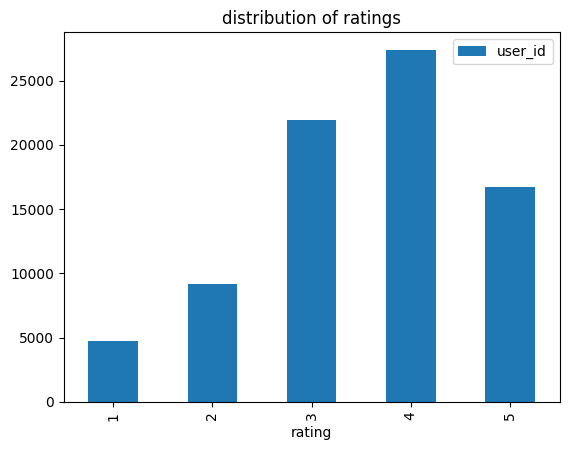

In [211]:
df_train[["user_id", "rating"]].groupby("rating").count().plot(kind="bar", title="distribution of ratings")

In [212]:
df_train.head(10).to_dict()

{'user_id': {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1},
 'movie_id': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 7, 6: 8, 7: 9, 8: 11, 9: 13},
 'rating': {0: 5, 1: 3, 2: 4, 3: 3, 4: 3, 5: 4, 6: 1, 7: 5, 8: 2, 9: 5}}

In [213]:
df_train.head(400).pivot("user_id", "movie_id", "rating")

movie_id,1,2,3,4,5,7,8,9,10,11,...,493,494,495,496,497,501,502,503,504,505
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,4.0,1.0,5.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,NaN,NaN,NaN,2.0,4.0,4.0,NaN,NaN,...,5.0,4.0,4.0,4.0,4.0,5.0,4.0,3.0,3.0,4.0


In [214]:
critics_with_nan = df_train.pivot("movie_id", "user_id", "rating").to_dict()
critics_with_nan_test = df_test.pivot("movie_id", "user_id", "rating").to_dict()

In [215]:
# A dictionary of movie critics and their ratings of a small set of movies
critics_with_nan[1]

{1: 5.0,
 2: 3.0,
 3: 4.0,
 4: 3.0,
 5: 3.0,
 6: nan,
 7: 4.0,
 8: 1.0,
 9: 5.0,
 10: nan,
 11: 2.0,
 12: nan,
 13: 5.0,
 14: nan,
 15: 5.0,
 16: 5.0,
 17: nan,
 18: 4.0,
 19: 5.0,
 20: nan,
 21: 1.0,
 22: 4.0,
 23: nan,
 24: nan,
 25: 4.0,
 26: 3.0,
 27: nan,
 28: 4.0,
 29: 1.0,
 30: 3.0,
 31: nan,
 32: 5.0,
 33: nan,
 34: 2.0,
 35: 1.0,
 36: nan,
 37: 2.0,
 38: 3.0,
 39: nan,
 40: 3.0,
 41: 2.0,
 42: 5.0,
 43: 4.0,
 44: nan,
 45: 5.0,
 46: 4.0,
 47: nan,
 48: 5.0,
 49: nan,
 50: 5.0,
 51: nan,
 52: 4.0,
 53: nan,
 54: nan,
 55: 5.0,
 56: nan,
 57: 5.0,
 58: 4.0,
 59: 5.0,
 60: nan,
 61: nan,
 62: nan,
 63: 2.0,
 64: nan,
 65: nan,
 66: 4.0,
 67: nan,
 68: 4.0,
 69: nan,
 70: nan,
 71: 3.0,
 72: nan,
 73: nan,
 74: nan,
 75: 4.0,
 76: nan,
 77: 4.0,
 78: nan,
 79: 4.0,
 80: nan,
 81: nan,
 82: nan,
 83: 3.0,
 84: nan,
 85: nan,
 86: nan,
 87: 5.0,
 88: 4.0,
 89: 5.0,
 90: nan,
 91: nan,
 92: nan,
 93: 5.0,
 94: 2.0,
 95: 4.0,
 96: nan,
 97: nan,
 98: nan,
 99: 3.0,
 100: nan,
 101: 2.

In [216]:
def get_dict_without_nuns(df):
    res = {}
    for user in df:
        user_movies = {}
        for key_item in df[user]:
            if str(df[user][key_item]) != "nan":
                user_movies[key_item] = df[user][key_item]
        res[user] = user_movies
    return res

critics = get_dict_without_nuns(critics_with_nan)
critics_test = get_dict_without_nuns(critics_with_nan_test)

In [217]:
critics[1]

{1: 5.0,
 2: 3.0,
 3: 4.0,
 4: 3.0,
 5: 3.0,
 7: 4.0,
 8: 1.0,
 9: 5.0,
 11: 2.0,
 13: 5.0,
 15: 5.0,
 16: 5.0,
 18: 4.0,
 19: 5.0,
 21: 1.0,
 22: 4.0,
 25: 4.0,
 26: 3.0,
 28: 4.0,
 29: 1.0,
 30: 3.0,
 32: 5.0,
 34: 2.0,
 35: 1.0,
 37: 2.0,
 38: 3.0,
 40: 3.0,
 41: 2.0,
 42: 5.0,
 43: 4.0,
 45: 5.0,
 46: 4.0,
 48: 5.0,
 50: 5.0,
 52: 4.0,
 55: 5.0,
 57: 5.0,
 58: 4.0,
 59: 5.0,
 63: 2.0,
 66: 4.0,
 68: 4.0,
 71: 3.0,
 75: 4.0,
 77: 4.0,
 79: 4.0,
 83: 3.0,
 87: 5.0,
 88: 4.0,
 89: 5.0,
 93: 5.0,
 94: 2.0,
 95: 4.0,
 99: 3.0,
 101: 2.0,
 105: 2.0,
 106: 4.0,
 109: 5.0,
 110: 1.0,
 111: 5.0,
 115: 5.0,
 116: 3.0,
 119: 5.0,
 122: 3.0,
 123: 4.0,
 124: 5.0,
 126: 2.0,
 127: 5.0,
 131: 1.0,
 133: 4.0,
 135: 4.0,
 136: 3.0,
 137: 5.0,
 138: 1.0,
 139: 3.0,
 141: 3.0,
 142: 2.0,
 144: 4.0,
 146: 4.0,
 147: 3.0,
 149: 2.0,
 152: 5.0,
 153: 3.0,
 156: 4.0,
 158: 3.0,
 162: 4.0,
 165: 5.0,
 166: 5.0,
 167: 2.0,
 168: 5.0,
 169: 5.0,
 172: 5.0,
 173: 5.0,
 176: 5.0,
 178: 5.0,
 179: 3.0,
 181: 

In [327]:
# make the same for items
def transformPrefs(prefs):
    result={}
    for person in prefs:
        for item in prefs[person]:
            result.setdefault(item,{})
    
            # Flip item and person
            result[item][person]=prefs[person][item]
    return result

movies=transformPrefs(critics)

In [328]:
movies

{1: {1: 5.0,
  2: 4.0,
  6: 4.0,
  13: 3.0,
  16: 5.0,
  21: 5.0,
  25: 5.0,
  26: 3.0,
  42: 5.0,
  44: 4.0,
  54: 4.0,
  57: 5.0,
  58: 5.0,
  59: 2.0,
  62: 2.0,
  63: 3.0,
  65: 3.0,
  70: 4.0,
  72: 4.0,
  73: 2.0,
  75: 4.0,
  77: 5.0,
  79: 4.0,
  81: 4.0,
  82: 4.0,
  84: 2.0,
  89: 5.0,
  92: 4.0,
  93: 5.0,
  97: 4.0,
  99: 4.0,
  101: 3.0,
  102: 3.0,
  108: 4.0,
  120: 4.0,
  121: 4.0,
  124: 3.0,
  130: 5.0,
  134: 5.0,
  137: 3.0,
  138: 4.0,
  144: 4.0,
  151: 5.0,
  162: 4.0,
  168: 5.0,
  174: 3.0,
  178: 4.0,
  182: 4.0,
  184: 4.0,
  193: 4.0,
  198: 4.0,
  199: 1.0,
  200: 5.0,
  201: 3.0,
  202: 3.0,
  209: 5.0,
  210: 5.0,
  216: 4.0,
  230: 5.0,
  231: 3.0,
  235: 4.0,
  242: 4.0,
  243: 4.0,
  244: 4.0,
  248: 3.0,
  249: 4.0,
  251: 4.0,
  252: 5.0,
  253: 5.0,
  254: 3.0,
  256: 5.0,
  262: 3.0,
  263: 5.0,
  265: 5.0,
  275: 4.0,
  276: 5.0,
  277: 4.0,
  290: 5.0,
  291: 5.0,
  292: 4.0,
  293: 2.0,
  294: 5.0,
  295: 4.0,
  296: 5.0,
  297: 3.0,
  298: 5.0,

### Extra functions

In [246]:
# Returns the Pearson correlation coefficient for p1 and p2
def sim_pearson(prefs,p1,p2):
    # Get the list of mutually rated items
    n_both = 0
    si={}
    for item in prefs[p1]: 
        if item in prefs[p2]: 
            si[item]=1
            n_both += 1

     # if they are no ratings in common, return 0
    if len(si)==0: 
        return 0

    # The number of mutually rated movies
    n=len(si)
  
    # Sums of all the preferences
    sum1=sum([prefs[p1][it] for it in si])
    sum2=sum([prefs[p2][it] for it in si])
  
    # Sums of the squares
    sum1Sq=sum([pow(prefs[p1][it],2) for it in si])
    sum2Sq=sum([pow(prefs[p2][it],2) for it in si])
  
    # Sum of the products
    pSum=sum([prefs[p1][it]*prefs[p2][it] for it in si])
  
    # Calculate r (Pearson score)
    num=pSum-(sum1*sum2/n)
    den=sqrt((sum1Sq-pow(sum1,2)/n)*(sum2Sq-pow(sum2,2)/n))
    if den==0: 
        return 0
    
    r=num/den
    
    # added this for removing simmilarity by less than 10 movies
    if n_both / 10 < 1: 
        return r * n_both / 10
    else:
        return r

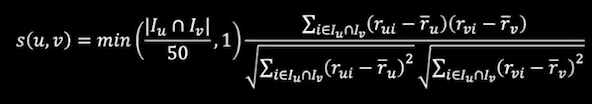

***if the neigbourhood (similar users or items to a target user or a certain item) is too small, it makes high simmilarity by little set of common items, where we can fix it with new factor. I gridded the constant 10***

In [253]:
sim_pearson(critics, 1, 5)

0.14783336664417163

In [248]:
# Returns the best matches for person from the prefs dictionary. 
# Number of results and similarity function are optional params.

def topMatches(prefs, person, n=5, similarity=sim_pearson):
    scores=[(similarity(prefs,person,other), other)
        for other in prefs if other!=person]
    # Descending sorting
    scores.sort( )
    scores.reverse( )
    return scores[0:n]

In [249]:
topMatches(critics, 1, n=5)

[(0.8448192338623111, 69),
 (0.8416650799680416, 329),
 (0.7957040966440954, 320),
 (0.7863336509949345, 115),
 (0.7690614556304467, 21)]

### Movie recommendation (User-based approach)

In [256]:
# Gets recommendations for a person by using a weighted average
# of every other user's rankings

def getRecommendations(prefs,person,similarity=sim_pearson):
    totals={}
    simSums={}
    for other in prefs:
        # don't compare me to myself
        if other==person: 
            continue
        sim=similarity(prefs,person,other)
        # ignore scores of zero or lower
        if sim<=0: 
            continue
        for item in prefs[other]:
            # only score movies I haven't seen yet
            if item not in prefs[person] or prefs[person][item]==0:
                # Similarity * Score
                totals.setdefault(item,0)
                totals[item]+=prefs[other][item]*sim
                # Sum of similarities
                simSums.setdefault(item,0)
                simSums[item]+=sim
    # Create the normalized list with hand made correction of clipping rating on both sides for rating from 1 to 5
    # if we don't need to predict the most relevant movie
    rankings=[]
    for item, total in totals.items( ):
        result = total / simSums[item]
        if result < 1: result = 1
        if result > 5: result = 5
        rankings.append((result, item))
    # Return the sorted list
    rankings.sort( )
    rankings.reverse( )
    return rankings

In [322]:
getRecommendations(critics, 1)[:25]

[(5.0, 1656),
 (5.0, 1599),
 (5.0, 1500),
 (5.0, 1472),
 (5.0, 1467),
 (5.0, 1293),
 (5.0, 1201),
 (5, 1189),
 (5, 1122),
 (4.922916844825155, 1449),
 (4.8905819235666375, 851),
 (4.76326785012388, 1064),
 (4.7481211742074585, 1592),
 (4.689856297650971, 1368),
 (4.556308835273559, 641),
 (4.545127297767585, 1131),
 (4.5414214827344415, 408),
 (4.527500900707468, 1367),
 (4.523627089038647, 1594),
 (4.508637606432117, 483),
 (4.491959884343838, 64),
 (4.4887787229213565, 318),
 (4.466324875156074, 1639),
 (4.450636707409855, 513),
 (4.432168163414839, 12)]

In [323]:
# only for new movies
critics[1][6]

KeyError: 6

In [111]:
critics_test[1][6]

5.0

In [350]:
# mae or rmse
def get_metric(prefs, prefs_test, neighbours, name="mae"):
    metric = 0
    n = 0
    
    for person in prefs:
        
        if person not in prefs_test:
            continue
        
        # select num of neighbours
        top_n_neighbours = np.array(topMatches(prefs, person, neighbours))[:, 1]

        new_prefs = {}
        for elem in top_n_neighbours:
            new_prefs[elem] = prefs[elem].copy()
        new_prefs[person] = prefs[person].copy()
        
        # get recommendations
        recomendations = np.array(getRecommendations(new_prefs, person))
        recomendations_df = pd.DataFrame({"movie_id": recomendations[:, 1], "rating": recomendations[:, 0]})
            
        true_df = pd.DataFrame({"movie_id": prefs_test[person].keys(), "true_rating": prefs_test[person].values()})
        
        res_df = pd.merge(true_df, recomendations_df, on="movie_id", how="left")
        res_df["rating"] = res_df["rating"].fillna(0) # no answer from us
        
        n += len(res_df)
        
        if name == "mae":
            res_df["mae"] = np.abs(res_df["true_rating"] - res_df["rating"])
            metric += res_df["mae"].sum()
        else:
            res_df["rmse"] = (res_df["true_rating"] - res_df["rating"]) ** 2
            metric += res_df["rmse"].sum()

    if name == "rmse":
        return (metric / n) ** (0.5)
    else:
        return metric / n

In [351]:
# with standart formula
mae_indices, mae_metrics = [], []

for i in range(2, 102, 5):
    print(i)
    mae_indices.append(i)
    mae_metrics.append(get_metric(critics, critics_test, i, "mae"))

2
7
12
17
22
27
32
37
42
47
52
57
62
67
72
77
82
87
92
97


In [352]:
mae_df = pd.DataFrame({"n_neighbours": mae_indices, "mae": mae_metrics})

In [353]:
# with standart formula
rmse_indices, rmse_metrics = [], []

for i in range(2, 102, 5):
    print(i)
    rmse_indices.append(i)
    rmse_metrics.append(get_metric(critics, critics_test, i, "rmse"))

2
7
12
17
22
27
32
37
42
47
52
57
62
67
72
77
82
87
92
97


In [354]:
rmse_df = pd.DataFrame({"n_neighbours": rmse_indices, "rmse": rmse_metrics})

### Advanced approach

In [308]:
# adding normalisation on user behavior
def getNormedRecommendations(prefs,person,similarity=sim_pearson):
    totals={}
    simSums={}
    for other in prefs:
        # don't compare me to myself
        if other==person: 
            continue
            
        sim=similarity(prefs,person,other)
        # ignore scores of zero or lower
        if sim<=0: 
            continue
            
        # mean_rating of other person
        mean_rating = 0
        for item in prefs[other]:
            mean_rating += prefs[other][item]
        mean_rating /= len(prefs[other])
        
        # std rating of other person
        std_rating = 0
        for item in prefs[other]:
            std_rating += (prefs[other][item] - mean_rating) ** 2
        std_rating /= len(prefs[other])
        std_rating = std_rating ** 0.5
            
        for item in prefs[other]:
            # only score movies I haven't seen yet
            if item not in prefs[person] or prefs[person][item]==0:
                # Similarity * Score
                totals.setdefault(item,0)
                totals[item] += sim * (prefs[other][item] - mean_rating) / std_rating
                # Sum of similarities
                simSums.setdefault(item,0)
                simSums[item] += sim
    
    # mean rating of current person
    mean_rating = 0
    for item in prefs[person]:
        mean_rating += prefs[person][item]
    mean_rating /= len(prefs[person])
    
    # std rating of current person
    std_rating = 0
    for item in prefs[person]:
        std_rating += (prefs[person][item] - mean_rating) ** 2
    std_rating /= len(prefs[person])
    std_rating = std_rating ** 0.5
        
    # Create the normalized list with hand made correction of clipping rating on both sides for rating from 1 to 5
    # if we don't need to predict the most relevant movie
    rankings=[]
    for item, total in totals.items( ):
        result = std_rating * total / simSums[item] + mean_rating
        if result < 1: result = 1
        if result > 5: result = 5
        rankings.append((result, item))
        
    # Return the sorted list
    rankings.sort( )
    rankings.reverse( )
    return rankings

In [321]:
getNormedRecommendations(critics, 1)[:25]

[(5, 1656),
 (5, 1651),
 (5, 1650),
 (5, 1645),
 (5, 1642),
 (5, 1639),
 (5, 1636),
 (5, 1612),
 (5, 1599),
 (5, 1592),
 (5, 1585),
 (5, 1467),
 (5, 1449),
 (5, 1391),
 (5, 1368),
 (5, 1293),
 (5, 1131),
 (5, 1122),
 (5, 1064),
 (5, 913),
 (5, 851),
 (4.947454955139291, 867),
 (4.939129180978737, 1625),
 (4.9386055646029545, 408),
 (4.935000211247182, 1233)]

In [310]:
# mae or rmse
def get_advanced_metric(prefs, prefs_test, neighbours, name="mae"):
    metric = 0
    n = 0
    
    for person in prefs:
        
        if person not in prefs_test:
            continue
        
        # select num of neighbours
        top_n_neighbours = np.array(topMatches(prefs, person, neighbours))[:, 1]

        new_prefs = {}
        for elem in top_n_neighbours:
            new_prefs[elem] = prefs[elem].copy()
        new_prefs[person] = prefs[person].copy()
        
        # get recommendations
        recomendations = np.array(getNormedRecommendations(new_prefs, person))
        recomendations_df = pd.DataFrame({"movie_id": recomendations[:, 1], "rating": recomendations[:, 0]})
            
        true_df = pd.DataFrame({"movie_id": prefs_test[person].keys(), "true_rating": prefs_test[person].values()})
        res_df = pd.merge(true_df, recomendations_df, on="movie_id", how="left")
        res_df["rating"] = res_df["rating"].fillna(0) # no answer from us
        
        n += len(res_df)
        
        if name == "mae":
            res_df["mae"] = np.abs(res_df["true_rating"] - res_df["rating"])
            metric += res_df["mae"].sum()
        else:
            res_df["rmse"] = (res_df["true_rating"] - res_df["rating"]) ** 2
            metric += res_df["rmse"].sum()

    if name == "rmse":
        return (metric / n) ** (1/2)
    else:
        return metric / n

In [311]:
# with advanced formula
adv_mae_indices, adv_mae_metrics = [], []

for i in range(2, 102, 5):
    print(i)
    adv_mae_indices.append(i)
    adv_mae_metrics.append(get_advanced_metric(critics, critics_test, i, "mae"))

2
7
12
17
22
27
32
37
42
47
52
57
62
67
72
77
82
87
92
97


In [315]:
advanced_mae_df = pd.DataFrame({"n_neighbours": adv_mae_indices, "advanced_mae": adv_mae_metrics})

In [324]:
# with standart formula
adv_rmse_indices, adv_rmse_metrics = [], []

for i in range(2, 102, 5):
    print(i)
    adv_rmse_indices.append(i)
    adv_rmse_metrics.append(get_advanced_metric(critics, critics_test, i, "rmse"))

2
7
12
17
22
27
32
37
42
47
52
57
62
67
72
77
82
87
92
97


In [325]:
advanced_rmse_df = pd.DataFrame({"n_neighbours": adv_rmse_indices, "advanced_rmse": adv_rmse_metrics})

<AxesSubplot: title={'center': 'compare mae and advanced mae in user-based'}, xlabel='n_neighbours'>

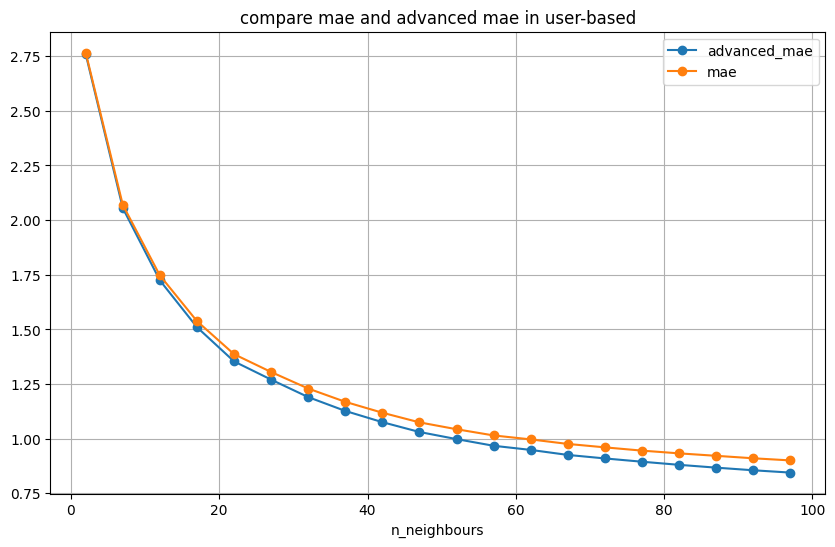

In [355]:
pd.merge(advanced_mae_df, mae_df, on="n_neighbours", how="left")\
.set_index("n_neighbours").plot(marker="o", figsize=(10, 6), grid="True", title="compare mae and advanced mae in user-based")

<AxesSubplot: title={'center': 'compare rmse and advanced rmse in user-based'}, xlabel='n_neighbours'>

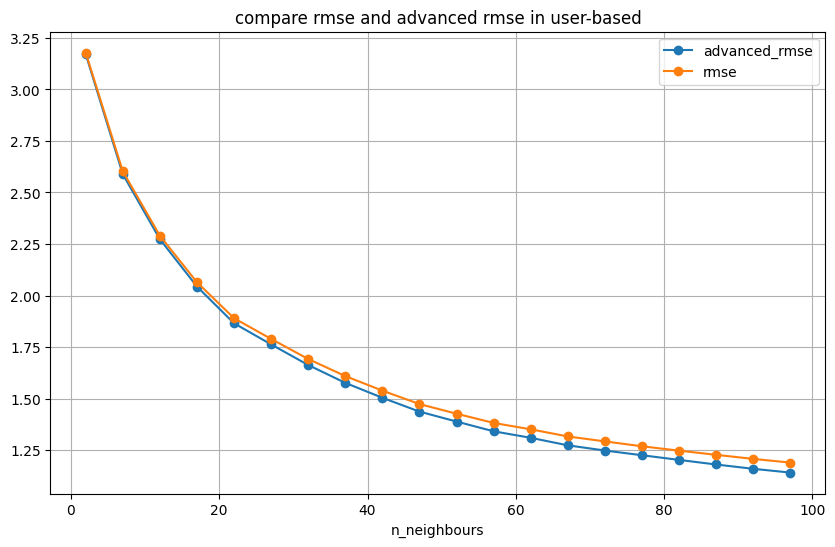

In [356]:
pd.merge(advanced_rmse_df, rmse_df, on="n_neighbours", how="left")\
.set_index("n_neighbours").plot(marker="o", figsize=(10, 6), grid="True", title="compare rmse and advanced rmse in user-based")

***With adding new neighbours, the metrics will increase as if test movies are not represented in neighbours we fill this value with 0 or mean. With new data we can see more relevant similar vectors for prediction. Also advanced mae and rmse gives us error smaller, on little numbers of neighbors it maybe not noticeably, however when the number becomes large, effect is significant, and noise component decreases.***

### Movie recommendation (Item-based approach) without any approvements

In [332]:
topMatches(movies, 1296, 5, sim_pearson)

[(0.7538495371547533, 294),
 (0.742264455392504, 332),
 (0.737083904943548, 242),
 (0.6380217049130142, 303),
 (0.5942028985507259, 288)]

In [334]:
# getRecommendations(movies, 1296, sim_distance)[:25]

[(4.940253573947598, 849),
 (4.873486333582738, 928),
 (4.86518708730741, 688),
 (4.8604474200950065, 507),
 (4.726145199033498, 136),
 (4.717844063282243, 88),
 (4.677515361670319, 118),
 (4.65916878768983, 583),
 (4.647079651406537, 4),
 (4.594849518444924, 907),
 (4.582728824680482, 909),
 (4.553056241659408, 850),
 (4.552575088945293, 636),
 (4.547419265707174, 225),
 (4.545191621762415, 420),
 (4.542446753144644, 312),
 (4.520708977761046, 469),
 (4.496815470566459, 765),
 (4.463021595339262, 272),
 (4.462918001067107, 777),
 (4.4598968367079035, 686),
 (4.459068086345122, 876),
 (4.435446765436643, 261),
 (4.428344965605296, 565),
 (4.426376440460947, 477)]

In [336]:
def calculateSimilarItems(prefs,n=10):
    # Create a dictionary of items showing which other items they are most similar to.
    result={}
    # Invert the preference matrix to be item-centric
    itemPrefs=transformPrefs(prefs)
    c=0
    for item in itemPrefs:
        # Status updates for large datasets
        c+=1
        if c % 100 == 0: print("%d / %d" % (c,len(itemPrefs)))
        # Find the most similar items to this one
        scores=topMatches(itemPrefs, item, n=n, similarity=sim_pearson)
        result[item]=scores
    return result

In [339]:
itemsim=calculateSimilarItems(critics)
itemsim

100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700 / 1650
800 / 1650
900 / 1650
1000 / 1650
1100 / 1650
1200 / 1650
1300 / 1650
1400 / 1650
1500 / 1650
1600 / 1650


{1: [(0.8565805033563155, 1053),
  (0.8216184139744055, 426),
  (0.7989769728790086, 936),
  (0.7698003589195006, 330),
  (0.7528949652702434, 539),
  (0.7516393997017519, 730),
  (0.7300413946291644, 966),
  (0.7242930276231766, 1199),
  (0.7137378387084142, 645),
  (0.70820696802355, 1121)],
 2: [(0.8598656863884369, 1090),
  (0.7974499177305758, 562),
  (0.7912240535768486, 1036),
  (0.7900760618359722, 254),
  (0.7694245205200122, 622),
  (0.767741935483871, 942),
  (0.7660323462854266, 1065),
  (0.7528916194166677, 664),
  (0.7460317460317459, 369),
  (0.726177314765688, 142)],
 3: [(0.8881532698344571, 952),
  (0.8347987115999219, 783),
  (0.7761362852996561, 554),
  (0.7573385038997049, 33),
  (0.7377820901250639, 254),
  (0.7297563831157797, 806),
  (0.683017127672663, 985),
  (0.6824161402886317, 1028),
  (0.6806118074441802, 1008),
  (0.6780635036208104, 407)],
 4: [(0.8736082383428209, 1203),
  (0.7651273926407443, 224),
  (0.7233393492970552, 1419),
  (0.7186764930337877, 8

In [347]:
def getRecommendedItems(prefs,itemMatch,user):
    userRatings=prefs[user]
    scores={}
    totalSim={}

    # Loop over items rated by this user
    for (item,rating) in userRatings.items():
        
        # Loop over items similar to this one
        for (similarity,item2) in itemMatch[item]:
            # Ignore if this user has already rated this item
            if item2 in userRatings: continue
            
            # Weighted sum of rating times similarity
            scores.setdefault(item2,0)
            scores[item2]+=similarity*rating
            
            # Sum of all the similarities
            totalSim.setdefault(item2,0)
            totalSim[item2]+=similarity
            
            if totalSim[item2]==0: totalSim[item2]=0.0000001 # to avoid divison by zero
    
    # Create the normalized list with hand made correction of clipping rating on both sides for rating from 1 to 5
    # if we don't need to predict the most relevant movie
    rankings=[]
    for item, score in scores.items( ):
        result = score / totalSim[item]
        if result < 1: result = 1
        if result > 5: result = 5
        rankings.append((result, item))

    # Return the rankings from highest to lowest
    rankings.sort( )
    rankings.reverse( )
    return rankings

In [348]:
getRecommendedItems(critics, itemsim, 1)[:30]

[(5.0, 1615),
 (5.0, 1483),
 (5.0, 1469),
 (5.0, 1451),
 (5.0, 1449),
 (5.0, 1335),
 (5.0, 1303),
 (5.0, 1277),
 (5.0, 1153),
 (5.0, 1147),
 (5.0, 1132),
 (5, 1121),
 (5, 1101),
 (5.0, 1055),
 (5.0, 1049),
 (5.0, 1020),
 (5.0, 1017),
 (5.0, 1010),
 (5.0, 994),
 (5.0, 971),
 (5.0, 969),
 (5.0, 960),
 (5.0, 953),
 (5.0, 934),
 (5.0, 933),
 (5.0, 925),
 (5.0, 922),
 (5.0, 902),
 (5.0, 886),
 (5.0, 882)]

In [360]:
# mae or rmse
def get_metric_item(prefs, prefs_test, moviesim, name="mae"):
    metric = 0
    n = 0
    
    for person in prefs:
        
        if person not in prefs_test:
            continue
        
        # get recommendations
        recomendations = np.array(getRecommendedItems(prefs, moviesim, person))
        recomendations_df = pd.DataFrame({"movie_id": recomendations[:, 1], "rating": recomendations[:, 0]})
            
        true_df = pd.DataFrame({"movie_id": prefs_test[person].keys(), "true_rating": prefs_test[person].values()})
        
        res_df = pd.merge(true_df, recomendations_df, on="movie_id", how="left")
        res_df["rating"] = res_df["rating"].fillna(0) # no answer from us
        
        n += len(res_df)
        
        if name == "mae":
            res_df["mae"] = np.abs(res_df["true_rating"] - res_df["rating"])
            metric += res_df["mae"].sum()
        else:
            res_df["rmse"] = (res_df["true_rating"] - res_df["rating"]) ** 2
            metric += res_df["rmse"].sum()

    if name == "rmse":
        return (metric / n) ** (0.5)
    else:
        return metric / n

In [361]:
# with standart formula
item_mae_indices, item_mae_metrics = [], []

for i in range(2, 102, 5):
    print(i)
    item_mae_indices.append(i)
    itemsim = calculateSimilarItems(critics, i)
    item_mae_metrics.append(get_metric_item(critics, critics_test, itemsim, "mae"))

2
100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700 / 1650
800 / 1650
900 / 1650
1000 / 1650
1100 / 1650
1200 / 1650
1300 / 1650
1400 / 1650
1500 / 1650
1600 / 1650
7
100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700 / 1650
800 / 1650
900 / 1650
1000 / 1650
1100 / 1650
1200 / 1650
1300 / 1650
1400 / 1650
1500 / 1650
1600 / 1650
12
100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700 / 1650
800 / 1650
900 / 1650
1000 / 1650
1100 / 1650
1200 / 1650
1300 / 1650
1400 / 1650
1500 / 1650
1600 / 1650
17
100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700 / 1650
800 / 1650
900 / 1650
1000 / 1650
1100 / 1650
1200 / 1650
1300 / 1650
1400 / 1650
1500 / 1650
1600 / 1650
22
100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700 / 1650
800 / 1650
900 / 1650
1000 / 1650
1100 / 1650
1200 / 1650
1300 / 1650
1400 / 1650
1500 / 1650
1600 / 1650
27
100 / 1650
200 / 1650
300 / 1650
400 / 1650
500 / 1650
600 / 1650
700

In [365]:
item_mae_df = pd.DataFrame({"n_neighbours": item_mae_indices, "item_mae": item_mae_metrics})

<AxesSubplot: title={'center': 'compare user and item based approches'}, xlabel='n_neighbours'>

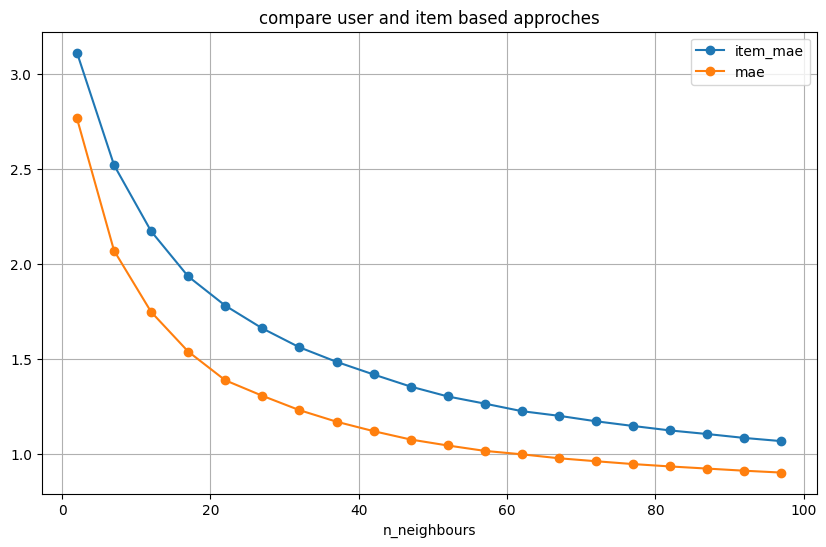

In [364]:
pd.merge(item_mae_df, mae_df, on="n_neighbours", how="left")\
.set_index("n_neighbours").plot(marker="o", figsize=(10, 6), grid="True", title="compare user and item based approches")

***User-based approch in this specific case shows better results as matrix is sparse for a lot of users in item-based method***

***In general, movie recommendation systems tend to recommend popular movies with high ratings more frequently than rare ones with high ratings.***

In [367]:
getNormedRecommendations(critics, 1)

[(5, 1656),
 (5, 1651),
 (5, 1650),
 (5, 1645),
 (5, 1642),
 (5, 1639),
 (5, 1636),
 (5, 1612),
 (5, 1599),
 (5, 1592),
 (5, 1585),
 (5, 1467),
 (5, 1449),
 (5, 1391),
 (5, 1368),
 (5, 1293),
 (5, 1131),
 (5, 1122),
 (5, 1064),
 (5, 913),
 (5, 851),
 (4.947454955139291, 867),
 (4.939129180978737, 1625),
 (4.9386055646029545, 408),
 (4.935000211247182, 1233),
 (4.928897523964861, 1189),
 (4.922593331817207, 896),
 (4.906190318384374, 1500),
 (4.905105407069117, 1452),
 (4.886744056906188, 1167),
 (4.874155293773679, 853),
 (4.852146321623356, 1193),
 (4.849545643175053, 1607),
 (4.848166641487374, 64),
 (4.846382217030363, 318),
 (4.84384429087696, 483),
 (4.827513023299933, 1155),
 (4.826529239738151, 272),
 (4.823257034774864, 1472),
 (4.808405098621552, 1235),
 (4.805912899022823, 1396),
 (4.796213754115599, 1629),
 (4.756006942371786, 12),
 (4.75300635684506, 1367),
 (4.739474644413498, 1398),
 (4.732813993429279, 313),
 (4.723202077147141, 174),
 (4.711391556653381, 793),
 (4.70835

In [374]:
recs = np.array(getNormedRecommendations(critics, 1))
recs_df = pd.DataFrame({"movie_id": recs[:, 1], "rating": recs[:, 0]})

In [371]:
recs_df.groupby("rating").count()

,movie_id
rating,
1.000000,9
1.023113,2
1.084123,1
1.098069,1
1.120876,1
...,...
4.935000,1
4.938606,1
4.939129,1


In [99]:
# # other similarity functions


# # Returns a distance-based similarity score for person1 and person2
# def sim_distance(prefs,person1,person2):
#     # Get the list of shared_items
#     si={}
#     for item in prefs[person1]:
#         if item in prefs[person2]:
#             si[item]=1
    
#     # if they have no ratings in common, return 0
#     if len(si)==0: return 0
    
#     # Add up the squares of all the differences
#     sum_of_squares=sum([pow(prefs[person1][item]-prefs[person2][item],2)
#     for item in prefs[person1] if item in prefs[person2]])
#     return 1/(1+sum_of_squares)


# # Returns a distance-based similarity score for person1 and person2
# def sim_kernel(prefs,person1,person2,alpha=0.3):
#     # Get the list of shared_items
#     si={}
#     for item in prefs[person1]:
#         if item in prefs[person2]:
#             si[item]=1
    
#     # if they have no ratings in common, return 0
#     if len(si)==0: return 0
    
#     # Add up the squares of all the differences and take the wieghted exponent
#     sum_of_squares=sum([pow(prefs[person1][item]-prefs[person2][item],2)
#     for item in prefs[person1] if item in prefs[person2]])
#     return exp(-alpha*sum_of_squares)

# sim_distance(critics, 1, 5), sim_kernel(critics, 1, 5)